<h1 align="center"><b>AgriYield Predictor</b></h1>
<h2 align="center"> - Manju Varshikha S </h2>


LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

print("Libraries imported successfully.")

Libraries imported successfully.


LOAD DATASETS

In [2]:
fao_data = pd.read_csv("data/FAOSTAT_data_en_12-29-2025.csv")
crop_data = pd.read_csv("data/Crop_recommendation.csv")
print("\nFAOSTAT Dataset:")
fao_data.head()
print("Shape:", fao_data.shape)

print("\nCrop Dataset:")
crop_data.head()
print("Shape:", crop_data.shape)


FAOSTAT Dataset:
Shape: (5691, 15)

Crop Dataset:
Shape: (2200, 8)


In [3]:
fao_data['Item'].unique()[:40]
for i in fao_data['Item'].unique():
    print(i)

Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw
Apples
Apricots
Areca nuts
Bananas
Barley
Beans, dry
Cabbages
Cantaloupes and other melons
Carrots and turnips
Cashew nuts, in shell
Cassava, fresh
Castor oil seeds
Cauliflowers and broccoli
Cherries
Chick peas, dry
Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw
Chillies and peppers, green (Capsicum spp. and Pimenta spp.)
Cocoa beans
Coconuts, in shell
Coffee, green
Coir, raw
Cucumbers and gherkins
Eggplants (aubergines)
Figs
Ginger, raw
Grapes
Green garlic
Groundnuts, excluding shelled
Jute, raw or retted
Kenaf, and other textile bast fibres, raw or retted
Lemons and limes
Lentils, dry
Lettuce and chicory
Linseed
Maize (corn)
Mangoes, guavas and mangosteens
Millet
Mushrooms and truffles
Natural rubber in primary forms
Nutmeg, mace, cardamoms, raw
Okra
Onions and shallots, dry (excluding dehydrated)
Oranges
Other beans, green
Other berries and fruits of the genus vaccinium n.e.c.
Other citrus fruit,

In [4]:
for i in crop_data['label'].unique():
    print(i)

rice
maize
chickpea
kidneybeans
pigeonpeas
mothbeans
mungbean
blackgram
lentil
pomegranate
banana
mango
grapes
watermelon
muskmelon
apple
orange
papaya
coconut
cotton
jute
coffee


CLEAN & SPLIT FAO ITEM COLUMN

In [5]:
fao_data["Item"] = fao_data["Item"].str.split(r",|and")
fao_data = fao_data.explode("Item")
fao_data

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,Anise,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,badian,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,cori,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,er,2001,2001,ha,5.692710e+05,A,Official figure,NaN
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,cumin,2001,2001,ha,5.692710e+05,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5686,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2022,2022,kg/ha,3.537300e+03,A,Official figure,NaN
5687,QCL,Crops and livestock products,356,India,5510,Production,111.0,Wheat,2022,2022,t,1.077421e+08,A,Official figure,NaN
5688,QCL,Crops and livestock products,356,India,5312,Area harvested,111.0,Wheat,2023,2023,ha,3.140072e+07,A,Official figure,NaN
5689,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2023,2023,kg/ha,3.520700e+03,A,Official figure,NaN


STANDARDIZE CROP NAMES (MAPPING)

In [6]:
crop_mapping = {
    "Rice": "rice",
    "Maize (corn)": "maize",
    "Chick peas": "chickpea",
    "Pigeon peas": "pigeonpeas",
    "Lentils": "lentil",
    "Beans": "mothbeans",
    "Bananas": "banana",
    "Mangoes": "mango",
    "Grapes": "grapes",
    "Watermelons": "watermelon",
    "Cantaloupes ": "muskmelon",
    "Apples": "apple",
    "Oranges": "orange",
    "Papayas": "papaya",
    "Coconuts": "coconut",
    "Seed cotton": "cotton",
    "Jute": "jute",
    "Coffee": "coffee"
}
fao_data["Crop"] = fao_data["Item"].map(crop_mapping)

In [7]:
crop_data = crop_data.rename(columns={'label': 'Crop'})
crop_data

,N,P,K,temperature,humidity,ph,rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


Merging datasets

In [8]:
merged_data = crop_data.merge(
    fao_data,
    left_on="Crop",
    right_on="Crop",
    how="inner"
)

merged_data

,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2001,2001,ha,4.490000e+07,A,Official figure,NaN
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2001,2001,kg/ha,3.115800e+03,A,Official figure,NaN
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2001,2001,t,1.399000e+08,A,Official figure,NaN
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Area harvested,113.0,Rice,2002,2002,ha,4.117610e+07,A,Official figure,NaN
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Yield,113.0,Rice,2002,2002,kg/ha,2.616300e+03,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124195,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2022,2022,kg/ha,7.742000e+02,E,Estimated value,NaN
124196,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2022,2022,t,3.404065e+05,I,Value imputed by a receiving agency,NaN
124197,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Area harvested,1610.0,Coffee,2023,2023,ha,4.378620e+05,I,Value imputed by a receiving agency,NaN
124198,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Yield,1610.0,Coffee,2023,2023,kg/ha,7.602000e+02,E,Estimated value,NaN


In [9]:
merged_data = merged_data[merged_data["Element"] == "Production"]
merged_data

,N,P,K,temperature,humidity,ph,rainfall,Crop,Domain Code,Domain,...,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2001,2001,t,1.399000e+08,A,Official figure,NaN
5,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2002,2002,t,1.077303e+08,A,Official figure,NaN
8,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2003,2003,t,1.327890e+08,A,Official figure,NaN
11,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2004,2004,t,1.246971e+08,A,Official figure,NaN
14,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,QCL,Crops and livestock products,...,Production,113.0,Rice,2005,2005,t,1.376901e+08,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124187,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2019,2019,t,3.195000e+05,A,Official figure,NaN
124190,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2020,2020,t,2.980000e+05,A,Official figure,NaN
124193,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2021,2021,t,3.340000e+05,A,Official figure,NaN
124196,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,QCL,Crops and livestock products,...,Production,1610.0,Coffee,2022,2022,t,3.404065e+05,I,Value imputed by a receiving agency,NaN


In [10]:
merged_data['Crop'].value_counts()

Crop
rice          2300
maize         2300
chickpea      2300
pigeonpeas    2300
mothbeans     2300
lentil        2300
banana        2300
mango         2300
grapes        2300
watermelon    2300
muskmelon     2300
apple         2300
orange        2300
papaya        2300
coconut       2300
cotton        2300
jute          2300
coffee        2300
Name: count, dtype: int64

DROP IRRELEVANT COLUMNS

In [11]:
merged_data = merged_data.drop(columns=[
    'Domain Code','Domain','Area Code (M49)','Area',
    'Element Code','Element','Item Code (CPC)','Item',
    'Year','Year Code','Unit','Flag','Flag Description','Note'
])
merged_data

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.399000e+08
5,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.077303e+08
8,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.327890e+08
11,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.246971e+08
14,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1.376901e+08
...,...,...,...,...,...,...,...,...,...
124187,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,3.195000e+05
124190,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,2.980000e+05
124193,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,3.340000e+05
124196,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,3.404065e+05


Missing value and duplicate checks

In [12]:
print("Missing Values:\n", merged_data.isnull().sum())
print("\nDuplicate Rows:", merged_data.duplicated().sum())

merged_data = merged_data.drop_duplicates().reset_index(drop=True)

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Crop           0
Value          0
dtype: int64

Duplicate Rows: 600


Summary Statistics

In [13]:
merged_data.describe()
merged_data.nunique()

N               136
P               117
K                73
temperature    1800
humidity       1800
ph             1800
rainfall       1800
Crop             18
Value           408
dtype: int64

OUTLIER REMOVAL USING IQR

In [14]:
numeric_cols = ["N","P","K","temperature","humidity","ph","rainfall","Value"]

Q1 = merged_data[numeric_cols].quantile(0.25)
Q3 = merged_data[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

clean_data = merged_data[
    ~((merged_data[numeric_cols] < (Q1 - 1.5 * IQR)) |
      (merged_data[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("Before:", merged_data.shape)
print("After :", clean_data.shape)
clean_data.head()

Before: (40800, 9)
After : (29853, 9)


,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
2300,71,54,16,22.6136,63.690706,5.749914,87.759539,maize,13160200.0
2301,71,54,16,22.6136,63.690706,5.749914,87.759539,maize,11151700.0
2302,71,54,16,22.6136,63.690706,5.749914,87.759539,maize,14984300.0
2303,71,54,16,22.6136,63.690706,5.749914,87.759539,maize,14172000.0
2304,71,54,16,22.6136,63.690706,5.749914,87.759539,maize,14709900.0


In [15]:
clean_data['Crop'].value_counts()

Crop
lentil        2300
jute          2300
watermelon    2300
coconut       2300
cotton        2300
mango         2208
muskmelon     2200
coffee        2200
pigeonpeas    2116
maize         1900
banana        1900
orange        1620
chickpea      1564
papaya        1426
mothbeans     1219
Name: count, dtype: int64

In [16]:
clean_data.describe()
clean_data.nunique()

N               136
P                91
K                62
temperature    1352
humidity       1352
ph             1352
rainfall       1352
Crop             15
Value           332
dtype: int64

CORRELATION HEATMAP

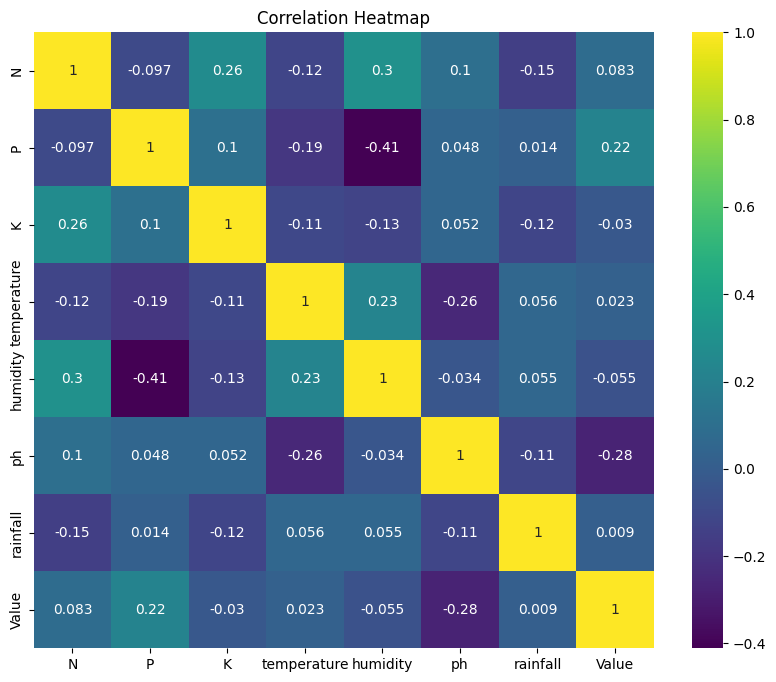

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(clean_data[numeric_cols].corr(), annot=True, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()

BOXPLOT

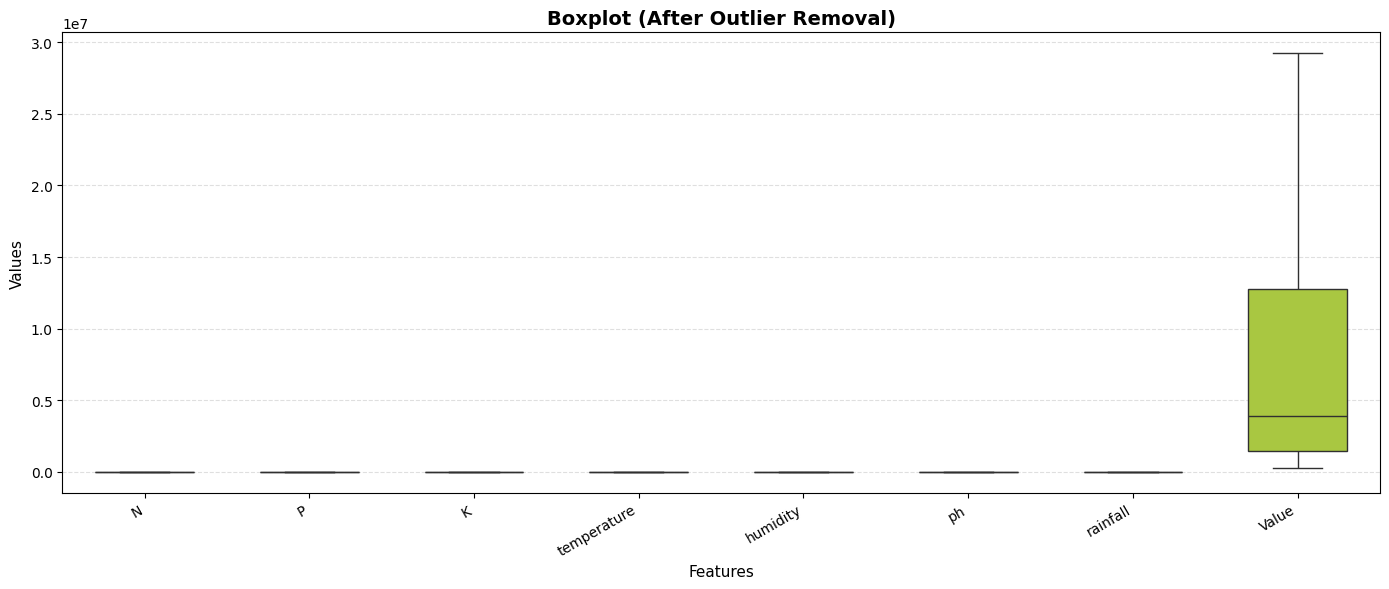

In [18]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=clean_data[numeric_cols],
    palette="viridis",
    width=0.6,
    showfliers=False   # hides extreme dots → cleaner
)

plt.title("Boxplot (After Outlier Removal)", fontsize=14, fontweight="bold")
plt.xlabel("Features", fontsize=11)
plt.ylabel("Values", fontsize=11)

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


MODEL TRAINING

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [20]:
features = clean_data.drop(columns=['Value', 'Element'], errors='ignore')
target = clean_data['Value']

# One-hot encode for models
features = pd.get_dummies(features, columns=['Crop'], drop_first=False)
feature_columns = features.columns 

# Scale numeric features
scaler = StandardScaler()
numeric_cols = features.select_dtypes(include=['int64', 'float64']).columns
features[numeric_cols] = scaler.fit_transform(features[numeric_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

print(f"Train Shape : {X_train.shape}")
print(f"Test Shape  : {X_test.shape}\n")

Train Shape : (23882, 22)
Test Shape  : (5971, 22)



In [21]:
def evaluate_model(model_name, y_tr, y_tr_pred, y_te, y_te_pred):
    print(f"--- {model_name} ---")
    print(f"Train R²: {r2_score(y_tr, y_tr_pred):.4f}")
    print(f"Test R²  : {r2_score(y_te, y_te_pred):.4f}")
    print(f"MAE      : {mean_absolute_error(y_te, y_te_pred):,.2f}")
    print(f"RMSE     : {np.sqrt(mean_squared_error(y_te, y_te_pred)):,.2f}\n")

def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, c="forestgreen", alpha=0.4)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             c="darkgreen", linewidth=2)
    plt.xlabel("Actual Yield")
    plt.ylabel("Predicted Yield")
    plt.title(title)
    plt.tight_layout()
    plt.show()

1.RIDGE REGRESSION

--- Ridge Regression ---
Train R²: 0.8698
Test R²  : 0.8639
MAE      : 1,861,807.57
RMSE     : 3,046,293.95



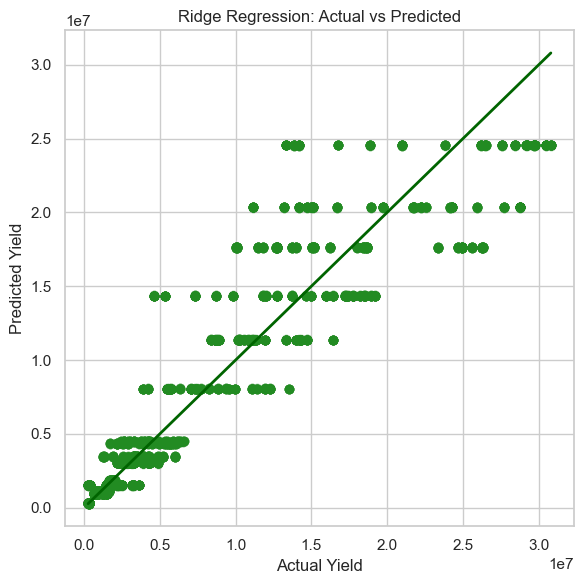

In [22]:
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)
ridge_train_pred = ridge_model.predict(X_train)
ridge_test_pred = ridge_model.predict(X_test)
evaluate_model("Ridge Regression", y_train, ridge_train_pred, y_test, ridge_test_pred)
plot_actual_vs_pred(y_test, ridge_test_pred, "Ridge Regression: Actual vs Predicted")

2A.RANDOM FOREST

--- Random Forest ---
Train R²: 0.8713
Test R²  : 0.8490
MAE      : 1,956,029.40
RMSE     : 3,208,989.66



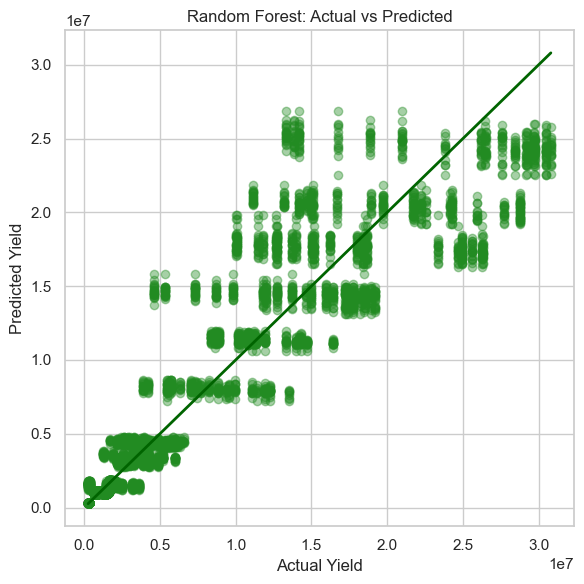

In [23]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
evaluate_model("Random Forest", y_train, rf_train_pred, y_test, rf_test_pred)
plot_actual_vs_pred(y_test, rf_test_pred, "Random Forest: Actual vs Predicted")

2B.RANDOM FOREST TUNED

Best RF Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
--- Random Forest Tuned ---
Train R²: 0.8708
Test R²  : 0.8524
MAE      : 1,926,210.26
RMSE     : 3,172,902.35



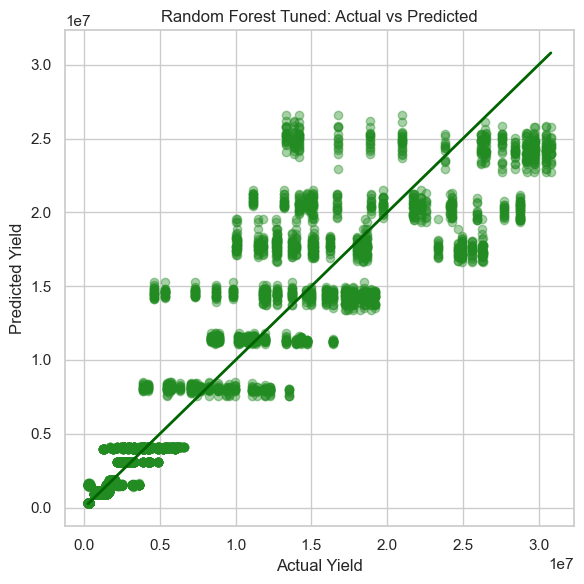

In [24]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print("Best RF Parameters:", grid_rf.best_params_)

rf_tuned_train_pred = best_rf.predict(X_train)
rf_tuned_test_pred = best_rf.predict(X_test)
evaluate_model("Random Forest Tuned", y_train, rf_tuned_train_pred, y_test, rf_tuned_test_pred)
plot_actual_vs_pred(y_test, rf_tuned_test_pred, "Random Forest Tuned: Actual vs Predicted")

3A.XGBOOST

--- XGBoost ---
Train R²: 0.8711
Test R²  : 0.8515
MAE      : 1,934,894.59
RMSE     : 3,182,033.05



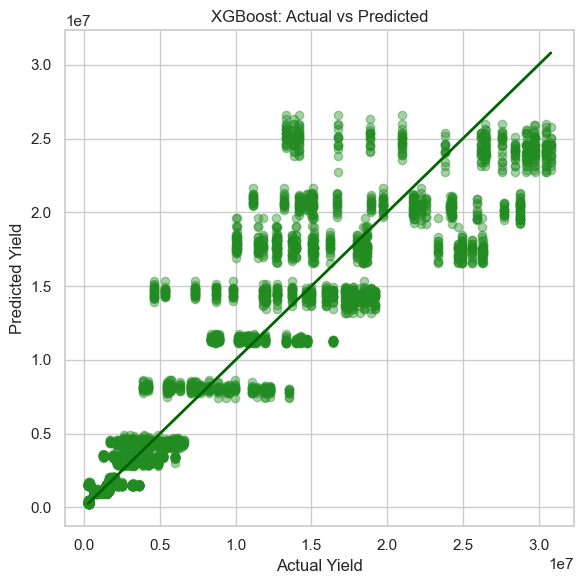

In [25]:
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                         subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror",
                         random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)
evaluate_model("XGBoost", y_train, xgb_train_pred, y_test, xgb_test_pred)
plot_actual_vs_pred(y_test, xgb_test_pred, "XGBoost: Actual vs Predicted")

3B.XGBOOST TUNED

Best XGBoost Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
--- XGBoost Tuned ---
Train R²: 0.8686
Test R²  : 0.8597
MAE      : 1,929,084.23
RMSE     : 3,093,217.44



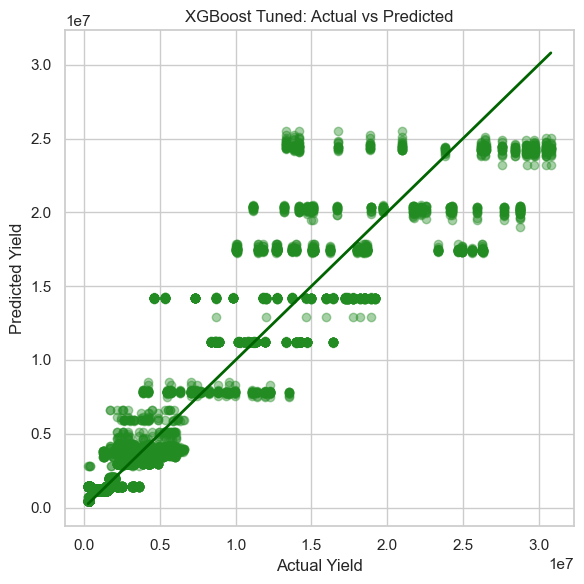

In [26]:
param_grid_xgb = {
    'n_estimators': [200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_xgb = GridSearchCV(XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
                        param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
print("Best XGBoost Parameters:", grid_xgb.best_params_)

xgb_tuned_train_pred = best_xgb.predict(X_train)
xgb_tuned_test_pred = best_xgb.predict(X_test)
evaluate_model("XGBoost Tuned", y_train, xgb_tuned_train_pred, y_test, xgb_tuned_test_pred)
plot_actual_vs_pred(y_test, xgb_tuned_test_pred, "XGBoost Tuned: Actual vs Predicted")

Overfitting / Underfitting Check

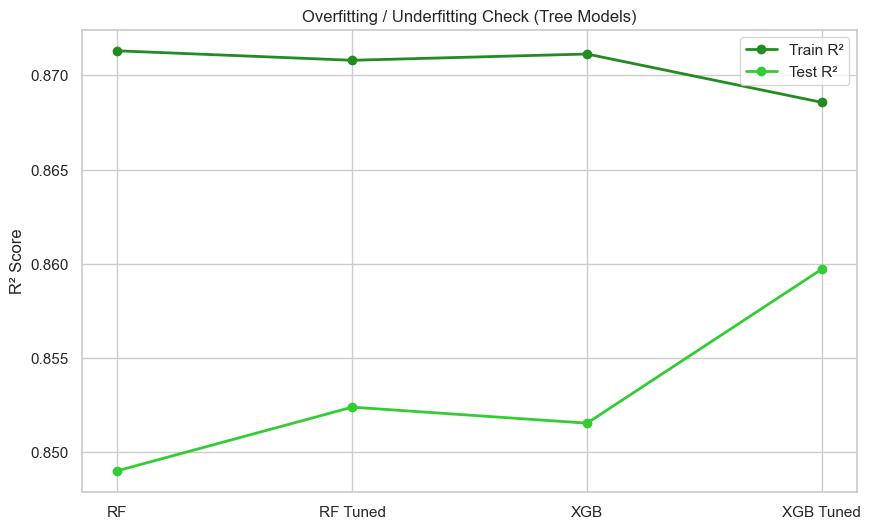

In [27]:
train_r2_tree = [r2_score(y_train, rf_train_pred),
                 r2_score(y_train, rf_tuned_train_pred),
                 r2_score(y_train, xgb_train_pred),
                 r2_score(y_train, xgb_tuned_train_pred)]

test_r2_tree = [r2_score(y_test, rf_test_pred),
                r2_score(y_test, rf_tuned_test_pred),
                r2_score(y_test, xgb_test_pred),
                r2_score(y_test, xgb_tuned_test_pred)]

tree_models = ["RF", "RF Tuned", "XGB", "XGB Tuned"]

plt.figure(figsize=(10,6))
plt.plot(tree_models, train_r2_tree, marker='o', label="Train R²", color='forestgreen', linewidth=2)
plt.plot(tree_models, test_r2_tree, marker='o', label="Test R²", color='limegreen', linewidth=2)
plt.title("Overfitting / Underfitting Check (Tree Models)")
plt.ylabel("R² Score")
plt.legend()
plt.show()

RMSE Before vs After Hyperparameter Tuning

C:\Users\manju varshikha\AppData\Local\Temp\ipykernel_32628\2283727120.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tree_models, y=rmse_tree, palette="Greens")


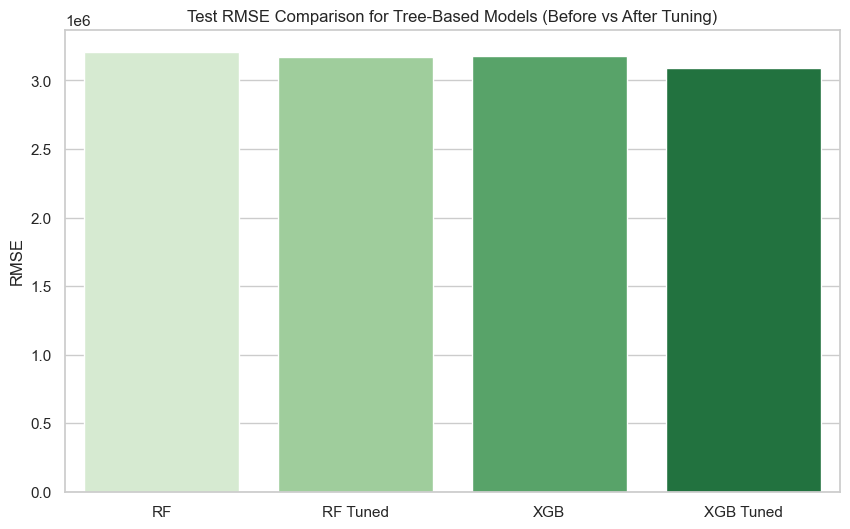

In [28]:
rmse_tree = [np.sqrt(mean_squared_error(y_test, rf_test_pred)),
             np.sqrt(mean_squared_error(y_test, rf_tuned_test_pred)),
             np.sqrt(mean_squared_error(y_test, xgb_test_pred)),
             np.sqrt(mean_squared_error(y_test, xgb_tuned_test_pred))]

plt.figure(figsize=(10,6))
sns.barplot(x=tree_models, y=rmse_tree, palette="Greens")
plt.title("Test RMSE Comparison for Tree-Based Models (Before vs After Tuning)")
plt.ylabel("RMSE")
plt.show()

Model Comparison Table

In [29]:
comparison_df = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest", "Random Forest Tuned",
              "XGBoost", "XGBoost Tuned"],
    "Test R2": [r2_score(y_test, ridge_test_pred),
                r2_score(y_test, rf_test_pred),
                r2_score(y_test, rf_tuned_test_pred),
                r2_score(y_test, xgb_test_pred),
                r2_score(y_test, xgb_tuned_test_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, ridge_test_pred)),
             np.sqrt(mean_squared_error(y_test, rf_test_pred)),
             np.sqrt(mean_squared_error(y_test, rf_tuned_test_pred)),
             np.sqrt(mean_squared_error(y_test, xgb_test_pred)),
             np.sqrt(mean_squared_error(y_test, xgb_tuned_test_pred))]
})

print("\nFinal Model Comparison:\n")
print(comparison_df.sort_values(by="Test R2", ascending=False))


Final Model Comparison:

                 Model   Test R2          RMSE
0     Ridge Regression  0.863943  3.046294e+06
4        XGBoost Tuned  0.859719  3.093217e+06
2  Random Forest Tuned  0.852399  3.172902e+06
3              XGBoost  0.851548  3.182033e+06
1        Random Forest  0.849022  3.208990e+06


Save / Load Best Model

In [40]:
joblib.dump(best_xgb, "xgb_final_model.joblib")
joblib.dump(list(feature_columns), "final_feature_columns.pkl")
print("✅ Best XGBoost model and feature columns saved successfully!")

✅ Best XGBoost model and feature columns saved successfully!
